In [51]:
import importlib

import kline_2day_forecaster.multilevel_chan
import kline_2day_forecaster

importlib.reload(
    kline_2day_forecaster.multilevel_chan
)

kline_2day_forecaster = importlib.reload(
    kline_2day_forecaster
)

from Common.CEnum import KL_TYPE

from kline_2day_forecaster import (
    ChanLevelSpec,
    MultiLevelChanConfig,
    build_multilevel_chan_features,
)


multilevel_config = MultiLevelChanConfig(
    input_csv="DataAPI/data/TQQQ_5M.csv",

    output_dir=(
        "outputs/"
        "tqqq_multilevel_chan_test"
    ),

    symbol="TQQQ",

    levels=(
        ChanLevelSpec(
            name="5m",
            rule="5min",
            kl_type=KL_TYPE.K_5M,
            window_bars=500,
        ),

        ChanLevelSpec(
            name="15m",
            rule="15min",
            kl_type=KL_TYPE.K_15M,
            window_bars=500,
        ),

        ChanLevelSpec(
            name="30m",
            rule="30min",
            kl_type=KL_TYPE.K_30M,
            window_bars=500,
        ),

        ChanLevelSpec(
            name="60m",
            rule="60min",
            kl_type=KL_TYPE.K_60M,
            window_bars=500,
        ),

        ChanLevelSpec(
            name="1d",
            rule="1D",
            kl_type=KL_TYPE.K_DAY,
            window_bars=500,
        ),
    ),

    base_bar_minutes=5,

    # TQQQ CSV时间戳按K线开始时间处理。
    # 例如09:30的5分钟K线在09:35才完整可用。
    timestamp_semantics="bar_start",

    start="2019-01-01",
    end="2026-05-30",

    verbose=True,
    progress_every_rows=2_500,

    save_level_csvs=True,
)


multilevel_result = (
    build_multilevel_chan_features(
        multilevel_config
    )
)

multilevel_result

[MultiLevelChan] 5m: resample=5min, window=500
[Chan] Starting 348,915 rows; rolling window=500
[Chan] 2,500/348,915 (0.7%) | 9.0 rows/s | elapsed 4.6m | ETA 644.2m
[Chan] 5,000/348,915 (1.4%) | 8.2 rows/s | elapsed 10.2m | ETA 701.8m
[Chan] 7,500/348,915 (2.1%) | 8.0 rows/s | elapsed 15.6m | ETA 709.8m
[Chan] 10,000/348,915 (2.9%) | 7.9 rows/s | elapsed 21.2m | ETA 717.4m
[Chan] 12,500/348,915 (3.6%) | 7.9 rows/s | elapsed 26.5m | ETA 713.3m
[Chan] 15,000/348,915 (4.3%) | 7.8 rows/s | elapsed 32.2m | ETA 716.0m
[Chan] 17,500/348,915 (5.0%) | 7.7 rows/s | elapsed 38.0m | ETA 718.9m
[Chan] 20,000/348,915 (5.7%) | 7.7 rows/s | elapsed 43.4m | ETA 713.5m
[Chan] 22,500/348,915 (6.4%) | 7.7 rows/s | elapsed 48.7m | ETA 705.8m
[Chan] 25,000/348,915 (7.2%) | 7.7 rows/s | elapsed 54.3m | ETA 703.6m
[Chan] 27,500/348,915 (7.9%) | 7.6 rows/s | elapsed 60.2m | ETA 703.9m
[Chan] 30,000/348,915 (8.6%) | 7.7 rows/s | elapsed 64.7m | ETA 687.8m
[Chan] 32,500/348,915 (9.3%) | 7.8 rows/s | elapsed 69.3

c:\Users\TonyTang\Documents\chan.py\kline_2day_forecaster\multilevel_chan.py:178: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[top_column] = strength.where(result[direction_column].gt(0), 0.0)
c:\Users\TonyTang\Documents\chan.py\kline_2day_forecaster\multilevel_chan.py:177: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[bottom_column] = strength.where(result[direction_column].lt(0), 0.0)
c:\Users\TonyTang\Documents\chan.py\kline_2day_forecaster\multilevel_chan.py:178: PerformanceWarning: DataFrame is highly fragmen

{'output_dir': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\tqqq_multilevel_chan_test',
 'aligned_path': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\tqqq_multilevel_chan_test\\multilevel_chan_aligned.csv',
 'core_path': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\tqqq_multilevel_chan_test\\multilevel_chan_core.csv',
 'level_paths': {'5m': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\tqqq_multilevel_chan_test\\levels\\5m_chan_features.csv',
  '15m': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\tqqq_multilevel_chan_test\\levels\\15m_chan_features.csv',
  '30m': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\tqqq_multilevel_chan_test\\levels\\30m_chan_features.csv',
  '60m': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\tqqq_multilevel_chan_test\\levels\\60m_chan_features.csv',
  '1d': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\tqqq_multilevel_chan_test\\levels\\1d_chan_features.csv'},
 'config_path': 'C:\\Users\\TonyTang\\Documents\\chan.p

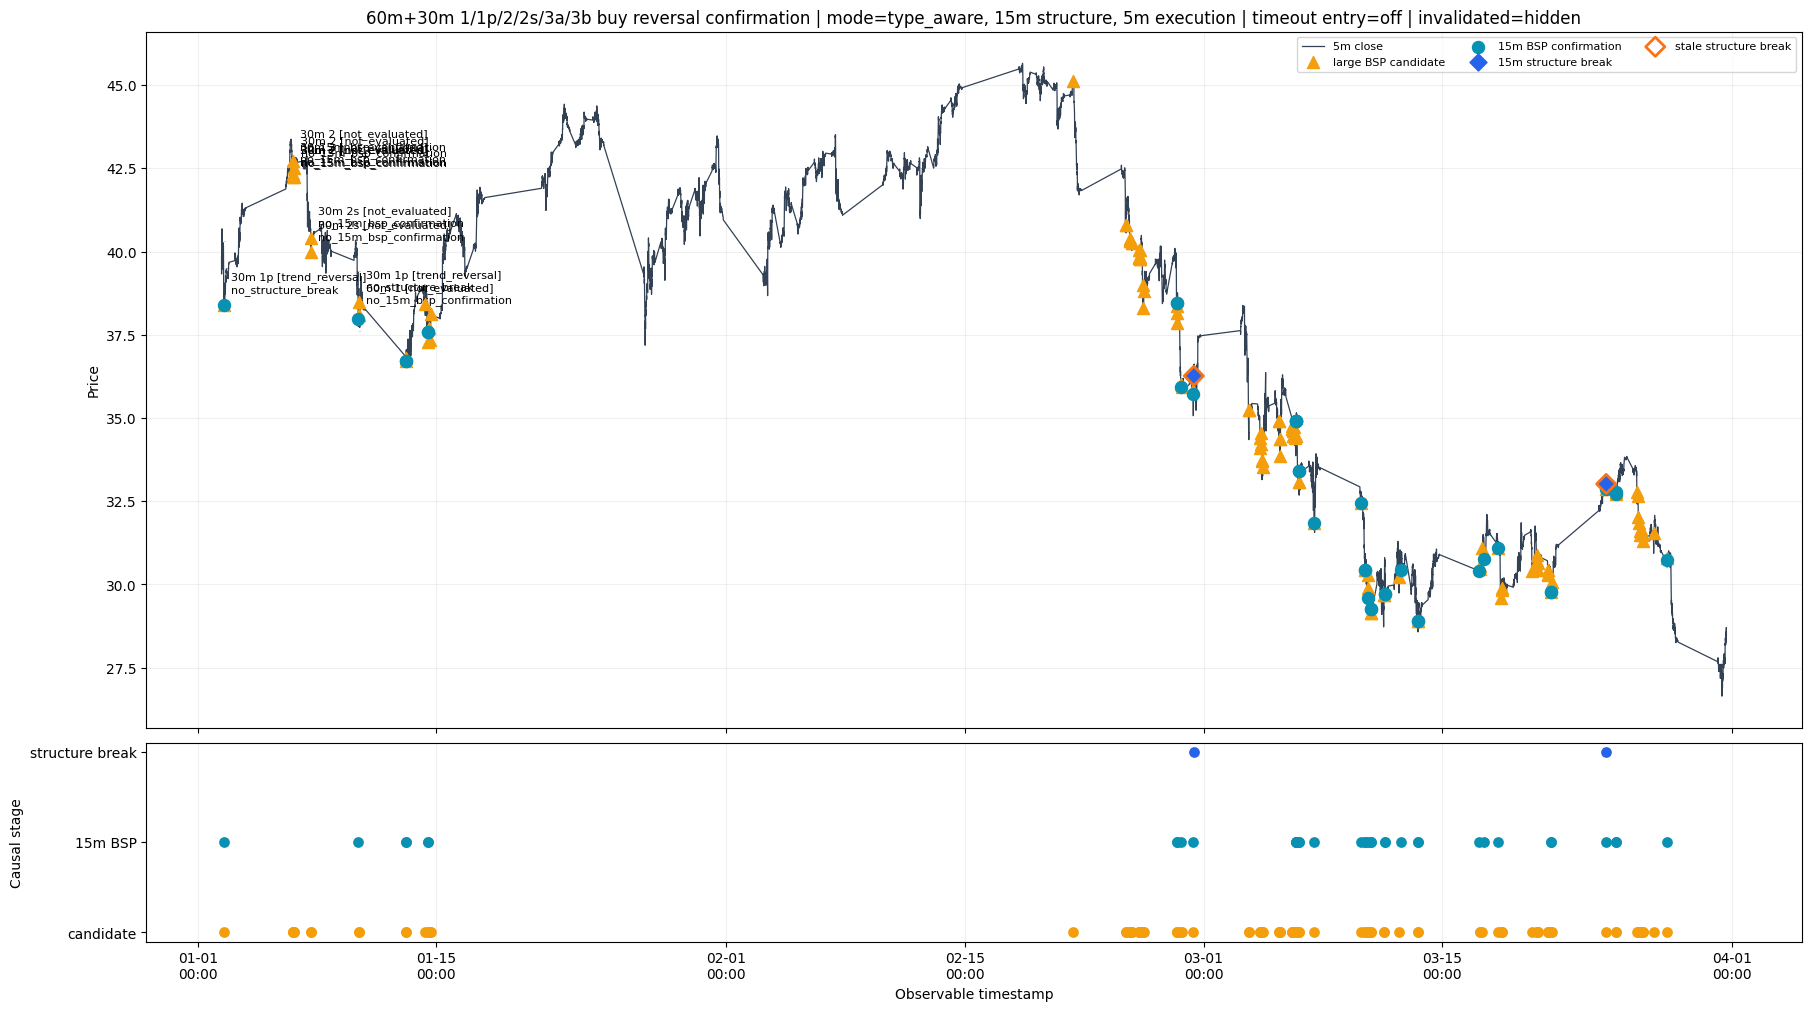

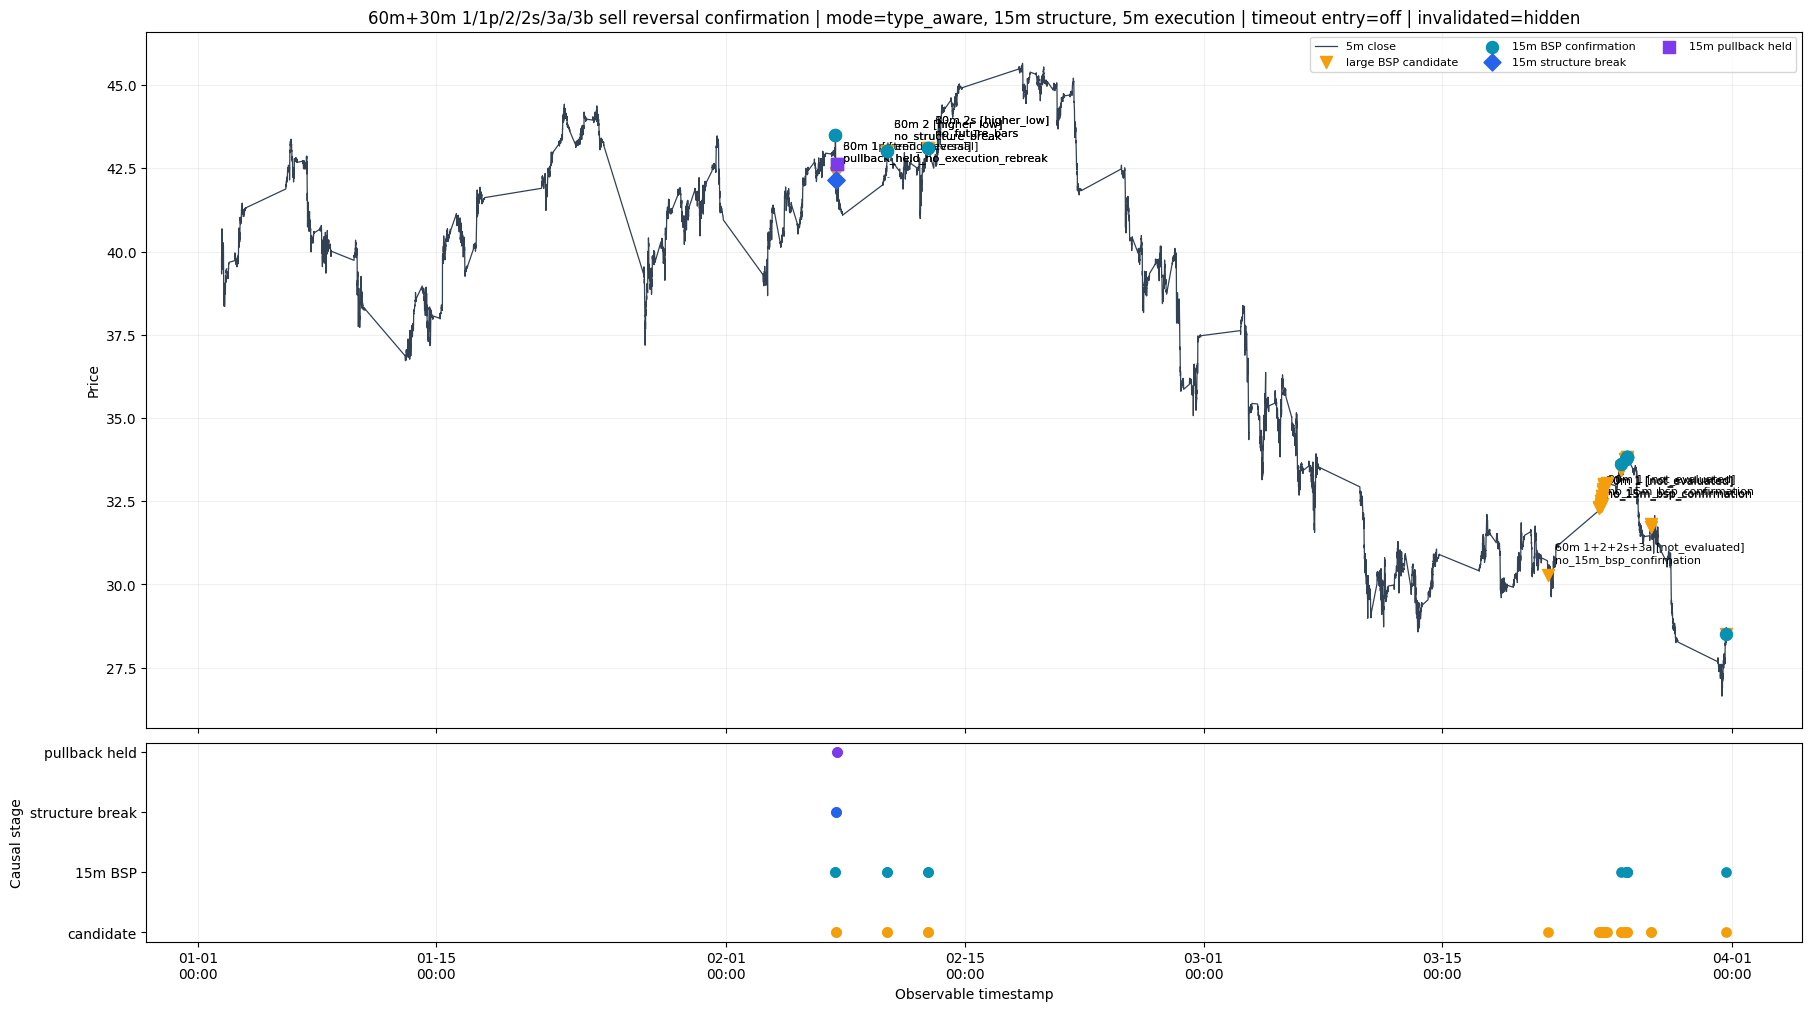

KeyError: "entry signals are missing columns: ['entry_price', 'entry_timestamp']"

In [9]:
import importlib

import pandas as pd

import kline_2day_forecaster.evaluation
import kline_2day_forecaster.multilevel_chan
import kline_2day_forecaster.multilevel_plotting
import kline_2day_forecaster.multilevel_reversal_plotting
import kline_2day_forecaster.multilevel_entry_evaluation
import kline_2day_forecaster


# 按依赖顺序重新加载
importlib.reload(
    kline_2day_forecaster.evaluation
)

importlib.reload(
    kline_2day_forecaster.multilevel_chan
)

importlib.reload(
    kline_2day_forecaster.multilevel_plotting
)

importlib.reload(
    kline_2day_forecaster.multilevel_reversal_plotting
)

importlib.reload(
    kline_2day_forecaster.multilevel_entry_evaluation
)

kline_2day_forecaster = importlib.reload(
    kline_2day_forecaster
)


from kline_2day_forecaster import (
    plot_multilevel_bsp_reversal_confirmation,
    plot_multilevel_entry_quality,
)

start_date = "2025-01-02 09:30:00"
end_date = "2025-03-31 16:00:00"
# ---------------------------------------
# 可以调整的入场参数
# ---------------------------------------
entry_parameters = {
    "confirmation_mode": "type_aware",

    # 必须出现同方向15m BSP
    "require_structure_level_bsp": True,

    "structure_level_bsp_types": (
        "1",
        "1p",
        "2",
        "2s",
        "3a",
        "3b",
    ),

    # 15m BSP最多可以提前30分钟
    "structure_bsp_before_minutes": 30,

    # 候选出现后最多等待180分钟的15m BSP
    "structure_bsp_after_minutes": 180,

    # 最多等待一个正常交易日完成15m结构确认
    "max_wait_minutes": 90,

    "break_buffer_atr": 0.10,
    "pullback_tolerance_atr": 0.25,

    "break_extension_limits_atr": {
        "trend_reversal": 1.50,
        "higher_low": 1.00,
        "center_retest": 0.75,
    },

    # 这里现在表示15m K线数量
    "break_delay_limits_bars": {
        "trend_reversal": 12,
        "higher_low": 8,
        "center_retest": 6,
    },

    "maximum_timeout_extension_atr": 1.00,

    # 第一轮先让60/30m候选 + 15m确认决定入场
    "require_execution_rebreak": True,

    # 不允许未经结构确认而超时强制入场
    "enter_at_timeout_if_valid": False,

    "show_invalidated": False,
}

reversal_results = {}

for selected_direction in (
    "buy",
    "sell",
):
    reversal_results[selected_direction] = (
        plot_multilevel_bsp_reversal_confirmation(
            multilevel_path=(
                "outputs/"
                "tqqq_multilevel_chan_test/"
                "multilevel_chan_aligned.csv"
            ),

            price_csv="DataAPI/data/TQQQ_5M.csv",

            start=start_date,
            end=end_date,

            # 60m和30m都作为候选级别
            large_levels=(
                "60m",
                "30m",
            ),

            large_bsp_types=(
                "1",
                "1p",
                "2",
                "2s",
                "3a",
                "3b",
            ),

            direction=selected_direction,

            # 15m负责BSP与价格结构确认
            structure_level="15m",

            # 5m只负责可选的精确执行
            execution_level="5m",

            **entry_parameters,
        )
    )


# 必须放在for循环结束以后
combined_entry_signals = pd.concat(
    [
        reversal_results["buy"]["summary"],
        reversal_results["sell"]["summary"],
    ],
    ignore_index=True,
)

combined_entry_signals

entry_quality_result = (
    plot_multilevel_entry_quality(
        entry_signals=combined_entry_signals,

        price_csv="DataAPI/data/TQQQ_5M.csv",

        start=start_date,
        end=end_date,

        # None表示同时评估所有类型
        bsp_types=None,

        # None表示同时评估buy和sell
        direction=None,

        # None表示保留所有入场方式
        entry_reasons=None,

        # 从入场后的下一根K线开始，
        # 到第2个后续交易日相同时刻
        horizon_trading_days=2,

        # --------------------------------
        # 交易结果阈值
        # --------------------------------

        # 3%止盈
        profit_target_pct=0.1,

        # 1.5%止损
        stop_loss_pct=0.05,

        # “好入场”至少需要达到2% MFE
        minimum_favorable_excursion_pct=0.02,

        # “好入场”最大允许1.5% MAE
        maximum_adverse_excursion_pct=0.015,

        # 同一根5m K线同时碰到止盈和止损时，
        # 保守地认为止损先发生
        same_bar_priority="stop",

        annotate_max=120,

        output_path=(
            "outputs/"
            "tqqq_multilevel_chan_test/"
            "plots/"
            "entry_quality_2025_q1.png"
        ),

        evaluation_csv=(
            "outputs/"
            "tqqq_multilevel_chan_test/"
            "plots/"
            "entry_quality_2025_q1.csv"
        ),

        show=True,
    )
)

entry_quality_result

In [54]:
import importlib

import kline_2day_forecaster.multilevel_chan
import kline_2day_forecaster.multilevel_plotting
import kline_2day_forecaster


# 1. 先刷新多级别缠论底层模块
importlib.reload(
    kline_2day_forecaster.multilevel_chan
)

# 2. 再刷新绘图模块
importlib.reload(
    kline_2day_forecaster.multilevel_plotting
)

# 3. 最后刷新包入口
kline_2day_forecaster = importlib.reload(
    kline_2day_forecaster
)


from kline_2day_forecaster import (
    plot_multilevel_bsp_confirmation,
)

plot_result = plot_multilevel_bsp_confirmation(
    # 多级别缠论架构生成的对齐数据
    multilevel_path=(
        "outputs/"
        "tqqq_multilevel_chan_test/"
        "multilevel_chan_aligned.csv"
    ),

    # 用于绘制底层5分钟价格
    price_csv="DataAPI/data/TQQQ_5M.csv",

    # 建议一次只看几天，否则信号会太密
    start="2020-03-01 09:30:00",
    end="2020-05-01 16:00:00",

    # 要检查的大级别
    large_level="60m",

    # 用于确认的小级别
    small_levels=(
        "5m",
        "15m",
        "30m",
    ),

    # 图中显示的大级别买卖点类型
    large_bsp_types=(
        "1",
        #"1p",
        "2",
        "2s",
        "3a",
    ),

    # 可以用于确认的小级别买卖点类型
    small_bsp_types=(
        "1",
        "1p",
        "2",
        "2s",
        "3a",
    ),

    # None = 同时显示buy和sell
    # 也可以设成 "buy" 或 "sell"
    direction=None,

    # 小级别BSP允许比大级别BSP提前多少分钟出现
    confirmation_before_minutes=60,

    # 小级别BSP允许在大级别BSP之后多少分钟出现
    confirmation_after_minutes=180,

    # 至少多少个不同小级别需要出现确认
    minimum_confirming_levels=1,

    # True：
    # 除了方向一致，还要求大小级别BSP类型有重合。
    # 例如大级别type 1，需要小级别也包含type 1。
    #
    # False：
    # 只要求方向相同，不要求BSP类型相同。
    require_type_overlap=False,

    annotate_max=20,

    output_path=(
        "outputs/"
        "tqqq_multilevel_chan_test/"
        "plots/"
        "60m_confirmed_by_small_levels.png"
    ),

    confirmation_csv=(
        "outputs/"
        "tqqq_multilevel_chan_test/"
        "plots/"
        "60m_confirmation_summary.csv"
    ),

    show=True,
)

plot_result

ImportError: cannot import name 'plot_direction_results' from 'kline_2day_forecaster.evaluation' (c:\Users\TonyTang\Documents\chan.py\kline_2day_forecaster\evaluation.py)

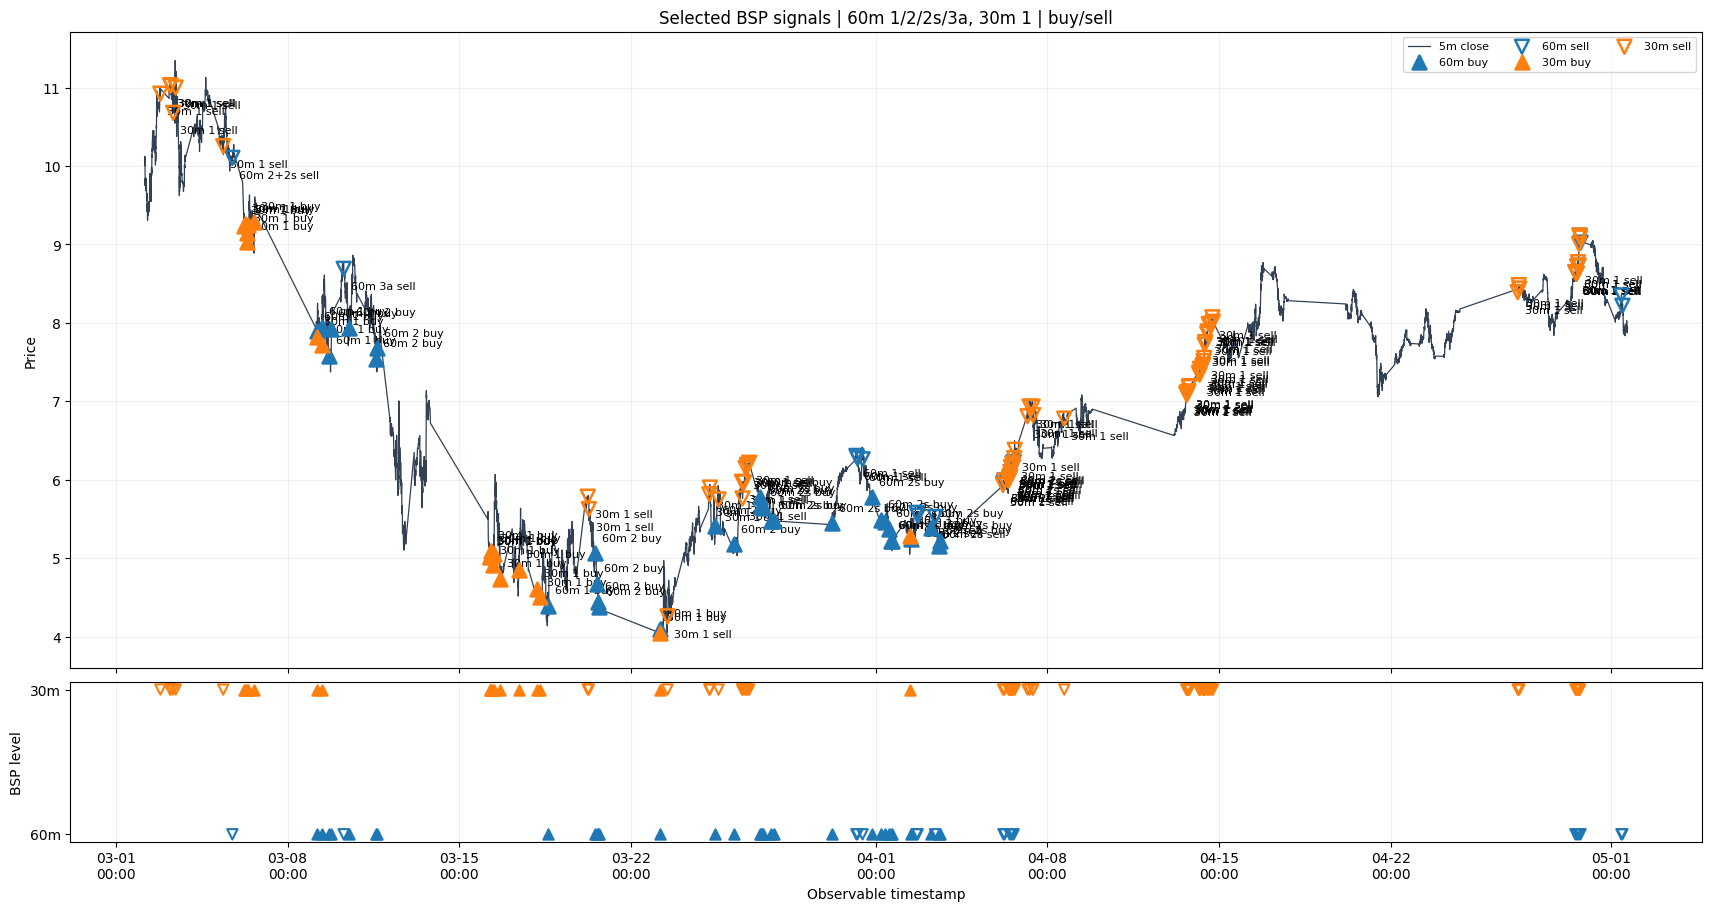

In [23]:
import importlib

import kline_2day_forecaster.multilevel_chan
import kline_2day_forecaster.multilevel_plotting
import kline_2day_forecaster


# 按依赖顺序重新加载
importlib.reload(
    kline_2day_forecaster.multilevel_chan
)

importlib.reload(
    kline_2day_forecaster.multilevel_plotting
)

kline_2day_forecaster = importlib.reload(
    kline_2day_forecaster
)


from kline_2day_forecaster import (
    plot_selected_multilevel_bsp,
)
selected_result = plot_selected_multilevel_bsp(
    multilevel_path=(
        "outputs/"
        "tqqq_multilevel_chan_test/"
        "multilevel_chan_aligned.csv"
    ),
    price_csv="DataAPI/data/TQQQ_5M.csv",

    start="2020-03-01 09:30:00",
    end="2020-05-01 16:00:00",

    bsp_selection={
        "60m": (
            "1",
            "2",
            "2s",
            "3a",
        ),
        "30m": (
            "1",
            #"2s",
        ),
        # "15m": (
        #     "3a",
        # ),
    },

    directions=(
        "buy",
        "sell",
    ),

    annotate_max=140,

    output_path=(
        "outputs/"
        "tqqq_multilevel_chan_test/"
        "plots/"
        "selected_multilevel_bsp.png"
    ),

    signals_csv=(
        "outputs/"
        "tqqq_multilevel_chan_test/"
        "plots/"
        "selected_multilevel_bsp.csv"
    ),

    show=True,
)

In [53]:
import importlib

import kline_2day_forecaster.multilevel_chan
import kline_2day_forecaster.multilevel_plotting
import kline_2day_forecaster.multilevel_reversal_plotting
import kline_2day_forecaster


# ---------------------------------------
# 按依赖顺序重新加载
# ---------------------------------------

importlib.reload(
    kline_2day_forecaster.multilevel_chan
)

importlib.reload(
    kline_2day_forecaster.multilevel_plotting
)

importlib.reload(
    kline_2day_forecaster.multilevel_reversal_plotting
)

kline_2day_forecaster = importlib.reload(
    kline_2day_forecaster
)


from kline_2day_forecaster import (
    plot_multilevel_bsp_reversal_confirmation,
)


# ---------------------------------------
# 新的结构反转确认图
# ---------------------------------------

reversal_result = (
    plot_multilevel_bsp_reversal_confirmation(
        multilevel_path=(
            "outputs/"
            "tqqq_multilevel_chan_test/"
            "multilevel_chan_aligned.csv"
        ),

        price_csv="DataAPI/data/TQQQ_5M.csv",

        # 建议一次查看1至2周，避免标签过密
        start="2020-01-02 09:30:00",
        end="2020-02-01 16:00:00",

        # --------------------------------
        # 大级别BSP候选
        # --------------------------------

        large_level="30m",

        large_bsp_types=(
            "2",
            "2s",
        ),

        direction="buy",

        # --------------------------------
        # 结构和执行级别
        # --------------------------------

        # 用15m判断下降结构是否被突破
        structure_level="15m",

        # 用5m判断回踩后的再次向上突破
        execution_level="5m",

        # --------------------------------
        # 最大确认等待时间
        # --------------------------------

        # 780分钟约等于两个正常交易日
        max_wait_minutes=180,

        # 使用候选点之前12根15m K线确定失效位置
        invalidation_lookback_bars=12,

        # --------------------------------
        # ATR和枢轴参数
        # --------------------------------

        atr_period=14,

        # 一个15m枢轴需要：
        # 左边2根 + 当前1根 + 右边2根
        pivot_left_bars=2,
        pivot_right_bars=2,

        # 收盘价需要突破结构高点：
        # structure_high + 0.10 × ATR
        break_buffer_atr=0.10,

        # 回踩允许短暂低于原突破位：
        # reference_high - 0.25 × ATR
        pullback_tolerance_atr=0.25,

        # True：
        # 回踩确认后，还要等待5m重新突破冲高点才入场。
        #
        # False：
        # 15m回踩枢轴得到确认后直接作为入场确认。
        require_execution_rebreak=True,

        enter_at_timeout_if_valid=True,

        show_invalidated=False,

        annotate_max=10,

        output_path=(
            "outputs/"
            "tqqq_multilevel_chan_test/"
            "plots/"
            "60m_2_buy_reversal_confirmation.png"
        ),

        signals_csv=(
            "outputs/"
            "tqqq_multilevel_chan_test/"
            "plots/"
            "60m_2_buy_reversal_confirmation.csv"
        ),

        show=True,
    )
)

reversal_result

ImportError: cannot import name 'plot_direction_results' from 'kline_2day_forecaster.evaluation' (c:\Users\TonyTang\Documents\chan.py\kline_2day_forecaster\evaluation.py)

In [52]:
import importlib

import kline_2day_forecaster.multilevel_chan
import kline_2day_forecaster.multilevel_plotting
import kline_2day_forecaster.multilevel_reversal_plotting
import kline_2day_forecaster


# ---------------------------------------
# 重新加载
# ---------------------------------------

importlib.reload(
    kline_2day_forecaster.multilevel_chan
)

importlib.reload(
    kline_2day_forecaster.multilevel_plotting
)

importlib.reload(
    kline_2day_forecaster
    .multilevel_reversal_plotting
)

kline_2day_forecaster = importlib.reload(
    kline_2day_forecaster
)


from kline_2day_forecaster import (
    plot_multilevel_bsp_reversal_confirmation,
)


# ---------------------------------------
# 按BSP类型自动选择确认规则
# ---------------------------------------

reversal_result = (
    plot_multilevel_bsp_reversal_confirmation(
        multilevel_path=(
            "outputs/"
            "tqqq_multilevel_chan_test/"
            "multilevel_chan_aligned.csv"
        ),

        price_csv="DataAPI/data/TQQQ_5M.csv",

        start="2020-03-16 09:30:00",
        end="2020-06-01 16:00:00",

        large_level="60m",

        large_bsp_types=(
            "1",
            "1p",
            "2",
            "2s",
            "3a",
            "3b",
        ),

        direction="sell",

        structure_level="30m",
        execution_level="5m",

        confirmation_mode="type_aware",

        # --------------------------------
        # Structure break追价限制
        # --------------------------------

        break_extension_limits_atr={
            "trend_reversal": 1.50,
            "higher_low": 1.00,
            "center_retest": 0.75,
        },

        break_delay_limits_bars={
            "trend_reversal": 8,
            "higher_low": 4,
            "center_retest": 3,
        },

        # 超时入场也不能距离BSP太远
        maximum_timeout_extension_atr=1.00,

        # --------------------------------
        # 原有参数
        # --------------------------------

        max_wait_minutes=180,

        invalidation_lookback_bars=12,

        atr_period=14,

        pivot_left_bars=2,
        pivot_right_bars=2,

        break_buffer_atr=0.10,
        pullback_tolerance_atr=0.25,

        require_execution_rebreak=True,
        enter_at_timeout_if_valid=True,

        show_invalidated=False,

        annotate_max=10,

        output_path=(
            "outputs/"
            "tqqq_multilevel_chan_test/"
            "plots/"
            "60m_type_aware_confirmation.png"
        ),

        signals_csv=(
            "outputs/"
            "tqqq_multilevel_chan_test/"
            "plots/"
            "60m_type_aware_confirmation.csv"
        ),

        show=True,
    )
)

reversal_result

ImportError: cannot import name 'plot_direction_results' from 'kline_2day_forecaster.evaluation' (c:\Users\TonyTang\Documents\chan.py\kline_2day_forecaster\evaluation.py)